# VaR y TailVaR — Presente e Histórico

Este notebook calcula las siguientes métricas de riesgo para la cartera real:

| Métrica | Método | Descripción |
|---------|--------|-------------|
| **VaR** | Paramétrico | Distribución normal escalada al horizonte |
| **TailVaR / CVaR** | Paramétrico | Expected Shortfall bajo normalidad |

Se calculan tanto a **fecha presente** como su **evolución durante la implementación de la estrategia**.

**Horizonte temporal: 4 semanas (20 días de trading).**

In [1]:
import os
import sys
import importlib
import pandas as pd

monitoring_dir = os.getcwd()
if monitoring_dir not in sys.path:
    sys.path.insert(0, monitoring_dir)

import auxfun
import var_funciones as vf

importlib.reload(auxfun)
importlib.reload(vf)

tickers_bmk = auxfun.get_eurostoxx50_tickers()
pesos_bmk = auxfun.calcular_pesos_bmk_actuales(tickers_bmk)

PATH_OPERATIVA = os.path.join(monitoring_dir, "..", "Envios", "historico_operativa.xlsx")

CAPITAL_INICIAL = 10_000_000
FECHA_FIN = "14/05/2026"
HOJA = "Operativa"

VENTANA = 550
MIN_OBS = 250
LOOKBACK_DIAS = 900
LAMBDA = 0.94
NIVEL = 0.99
HORIZONTE = 20

In [2]:
hist, posiciones, pesos, precios, retornos_activos = auxfun.historico_posiciones_cartera(
    archivo=PATH_OPERATIVA, fecha_fin=FECHA_FIN, capital_inicial=CAPITAL_INICIAL,
    hoja=HOJA, incluir_costes=True, universo_tickers=tickers_bmk, lookback_dias=LOOKBACK_DIAS,
)

nav = hist["Valor cartera"]
fechas_on = pesos.index[pesos.abs().sum(axis=1) > 1e-12]
fecha_ini_on = fechas_on.min()

print(f"Periodo: {nav.index.min().date()} → {nav.index.max().date()}")
print(f"NAV actual: {nav.iloc[-1]:,.0f} €")
print(f"Activos actuales: {(pesos.iloc[-1].abs() > 1e-12).sum()}")
print(f"Peso invertido actual: {pesos.iloc[-1].abs().sum():.2%}")
print(f"Cash actual: {hist['Cash'].iloc[-1]:,.0f} €")


Periodo: 2023-09-25 → 2026-05-14
NAV actual: 10,324,754 €
Activos actuales: 16
Peso invertido actual: 99.97%
Cash actual: 3,399 €


In [3]:
df_riesgo = vf.calcular_riesgo_diario_posiciones(
    pesos=pesos, retornos_activos=retornos_activos, nav=nav, ventana=VENTANA,
    nivel=NIVEL, horizonte=HORIZONTE, lambda_=LAMBDA, min_obs=MIN_OBS, usar_media=True,
)

if df_riesgo.empty:
    raise ValueError("No se ha podido calcular el riesgo: revisa ventana, min_obs o histórico disponible.")

fecha_final = df_riesgo.index[-1]
fecha_fin_riesgo = fecha_final
nav_final = df_riesgo.loc[fecha_final, "NAV"]


In [4]:
ret_cartera_on = hist.loc[(hist.index >= fecha_ini_on) & (hist.index <= fecha_fin_riesgo), "Rentabilidad diaria"]
vol_cartera = vf.vol_anualizada_periodo(ret_cartera_on)

tickers_bmk_validos = pesos_bmk.index.intersection(retornos_activos.columns)
pesos_bmk_validos = pesos_bmk[tickers_bmk_validos] / pesos_bmk[tickers_bmk_validos].sum()

ret_bmk_on = (
    retornos_activos.loc[
        (retornos_activos.index >= fecha_ini_on) & (retornos_activos.index <= fecha_fin_riesgo),
        tickers_bmk_validos,
    ].fillna(0.0) @ pesos_bmk_validos
)
vol_bmk = vf.vol_anualizada_periodo(ret_bmk_on)

riesgo_bmk = vf.riesgo_benchmark_actual(
    pesos_bmk=pesos_bmk, retornos_activos=retornos_activos, fecha=fecha_final, nav=nav_final,
    ventana=VENTANA, nivel=NIVEL, horizonte=HORIZONTE, lambda_=LAMBDA, min_obs=MIN_OBS, usar_media=True,
)


,Actual,Medio,Benchmark
VaR %,-9.15%,-11.17%,-12.20%
TailVaR %,-11.16%,-12.99%,-14.17%
EaR %,+18.45%,+13.87%,+14.85%
EaR/VaR,2.02x,1.74x,1.22x
Volatilidad anualizada,18.67%,,21.87%


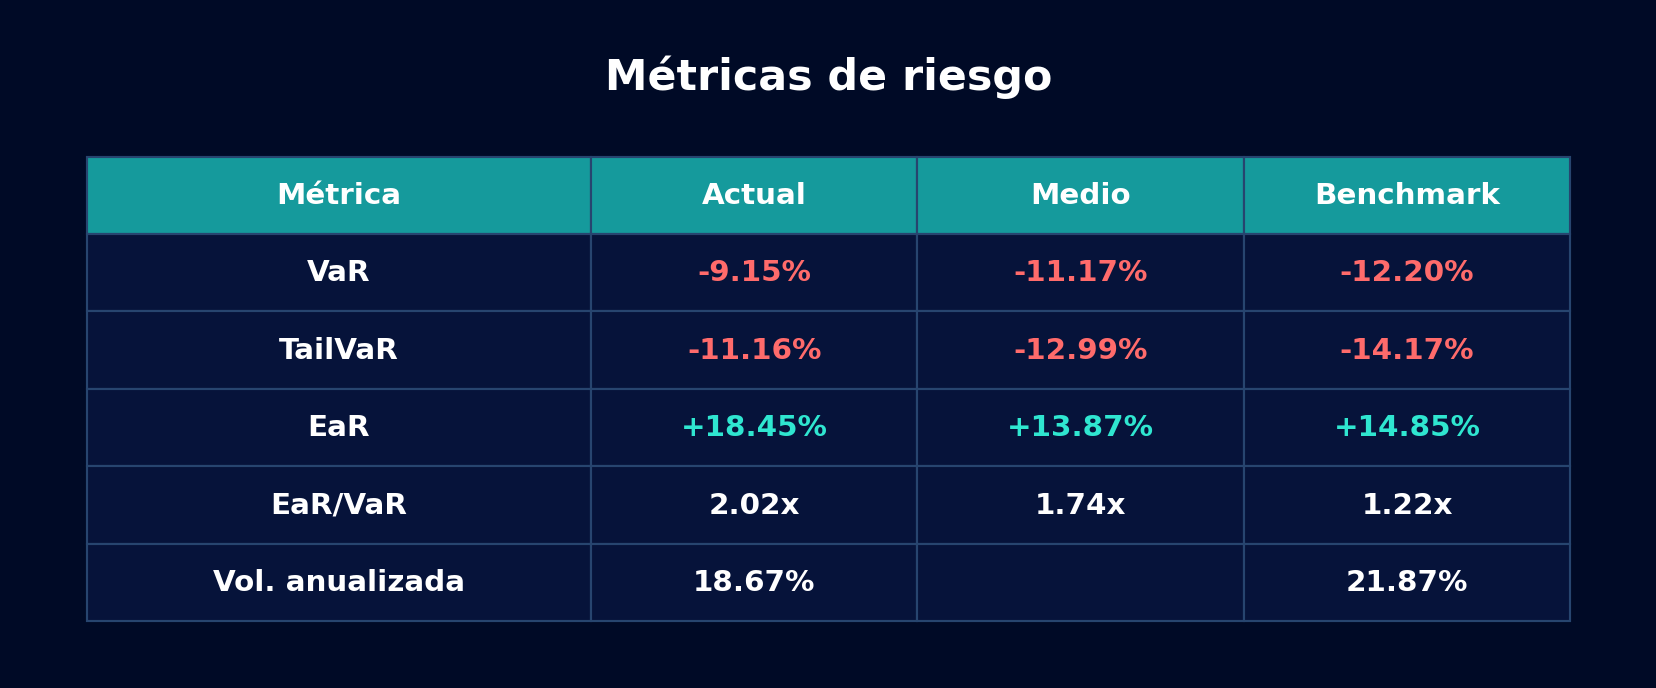

In [5]:
resumen = vf.resumen_riesgo(df_riesgo=df_riesgo, vol_cartera=vol_cartera, riesgo_bmk=riesgo_bmk, vol_bmk=vol_bmk)
resumen_fmt = vf.formatear_resumen_riesgo(resumen)

display(resumen_fmt)
fig, ax = vf.tabla_resumen_riesgo_presentacion(resumen, titulo="Métricas de riesgo")